```GPU - T4 GPU 세팅```

## 목표
- 한국어 분류 데이터셋을 활용한 한국어 토픽 분류 모델 구현해보기
- `데이터 준비부터 미세조정(파인튜닝) 훈련까지의 흐름을 경험`
- 모델과 토크나이저, FineTuning에 필요한 클래스를 직접 조작하며, 허깅페이스의 내부 동작에 대해 조금 더 깊이 있는 실습을 진행

In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

/content/drive/MyDrive/Colab Notebooks/딥러닝


In [ ]:
!pip -q install 'transformers[torch] == 4.44.2'
!pip -q install datasets

# transformers[torch] : transformers + PyTorch 백엔드를 사용하는 모델을 위한 추가 패키지 설치
# Hugging Face의 'datasets' : 다양한 공개 데이터셋을 쉽게 불러오고 사용할 수 있게 해주는 라이브러리

# ERROR: pip's dependency resolver~~
# → Colab 환경에 기본 설치된 gcsfs 버전이 최신(2025.3.2), transformers나 datasets 설치 과정에서 fsspec가 2025.3.0으로 설치/업데이트되어 충돌
# GCS(Google Cloud Storage)에 접근할 계획이 있다면 버전을 맞춰주는 것이 권장하나, 필요없음

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 21.3 MB/s eta 0:00:00


In [ ]:
# 그래픽 카드 사용을 알려주는 코드 (설정코드) 작성
import torch # Pytorch 딥러닝 프레임워크

In [ ]:
# GPU 사용 여부 확인
# GPU가 사용 가능하면 "cuda", 아니면 "cpu"를 device 변수에 할당
device = "cuda" if torch.cuda.is_available() else 'cpu'
device

# 현재 T4 GPU 사용 -> 'cuda'

'cuda'

## 시나리오

### 배경
- “스마트뉴스”는 <u>월간 **12만 건** 이상의 뉴스 헤드라인</u>을 처리하는 AI 기반 토픽 분류 플랫폼  
- YNAT 데이터셋(연합뉴스 헤드라인, 7개 주제)으로 학습된 일반 사전학습 모델은 <u>**도메인별 뉘앙스**</u>와 <u>**언론사별 어투**</u>를 구분하기 어려움  
- <u>**Fine-Tuning**</u>을 통해 KoELECTRA 기반 분류 모델을 <u>**IT·과학, 경제, 사회 등 7개 주제**</u>에 최적화해야 하는 과제 존재  

```python
# 주요 이해관계자
- NLP 연구팀         : 사전학습 모델 파인튜닝 및 하이퍼파라미터 튜닝  
- 데이터 엔지니어팀   : YNAT 데이터 로딩·전처리·토크나이저 적용 파이프라인 구축  
- 제품 기획팀         : 토픽 분류 서비스 요구사항 정의 및 결과 활용 방안 수립  
- DevOps/운영팀      : T4 GPU 환경에서 모델 학습·배포·모니터링 자동화  
- QA/테스트팀        : 분류 정확도 검증 및 혼동행렬 기반 개선 포인트 제안  
```

## 1. 데이터셋 로드
- Hugging Face datasets 활용 데이터 로드 해보기

In [ ]:
# 허깅페이스에 있는 데이터 로드용 함수가져오기
from datasets import load_dataset

> **YNAT 데이터셋**  
> - 연합뉴스(Yonhap News) 기사 제목(헤드라인)을 **7개 주제**로 분류  
> - 레이블 0 ~ 6 : `정치` / `경제` / `사회` / `생활·문화` / `세계` / `IT·과학` / `스포츠`
> - HuggingFace 링크 : https://huggingface.co/datasets/klue/klue#considerations-for-using-the-data

---

```python
> 원출처 : KLUE Benchmark 프로젝트
> - "Korean Language Understanding Evaluation"의 약자  
> - 한국어 자연어 이해(NLU) 전용 종합 벤치마크로 설계  
> - 기계 번역·문장 분류·개체명 인식·관계 추출 등 8개 태스크 포함

> 논문
> - "KLUE: Korean Language Understanding Evaluation"  
> - EMNLP 2021 학회 게재  
> - 한국어 특화 NLU 모델 평가를 위한 표준 데이터셋 및 메트릭 제안

> 대규모 한국어 토픽 분류 데이터 제공 목적  
> - 한국어 NLU 모델의 토픽 분류 성능을 객관적으로 비교·평가  
> - 연구자들이 일관된 지표로 모델 개선 효과를 검증할 수 있도록 지원
```

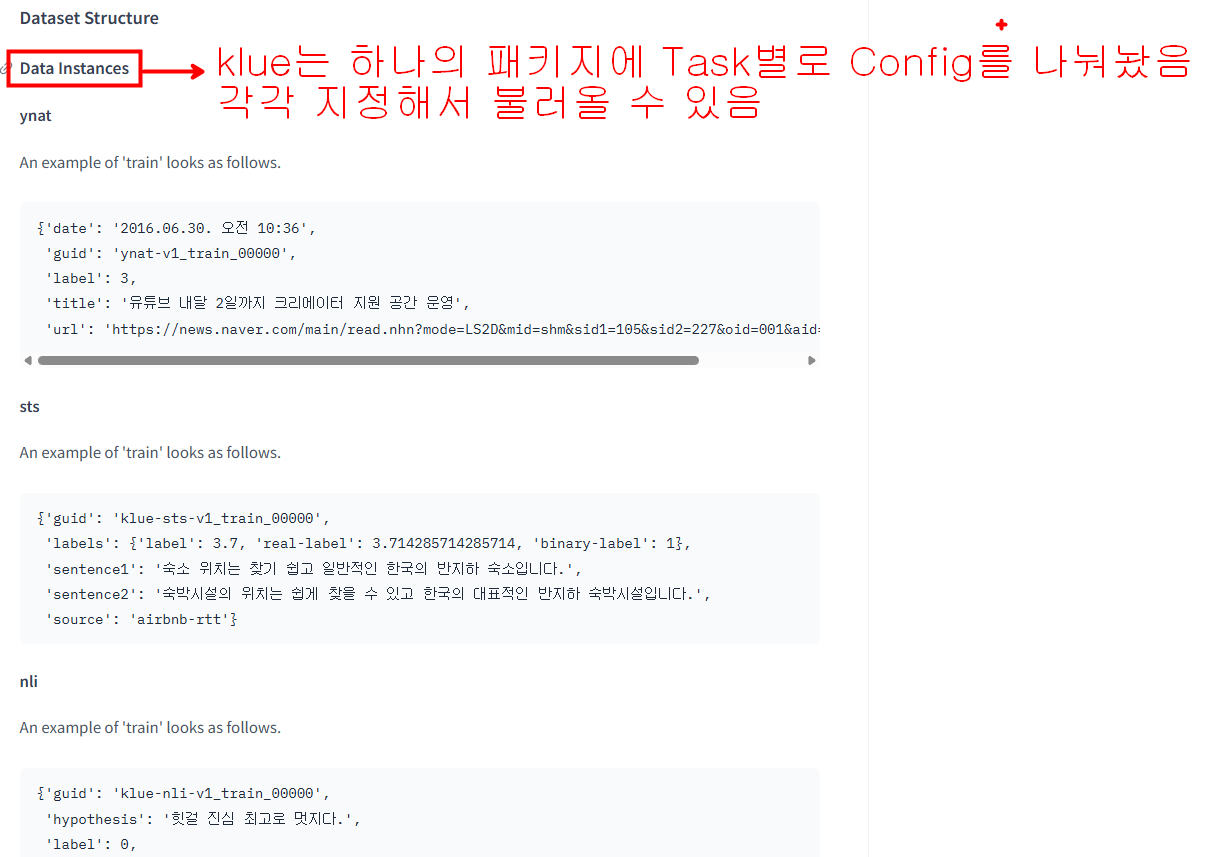

#### klue 데이터셋 각 Task별 핵심 필드 및 설명

| Task  | 예시 인스턴스 (train) 주요 필드                          | 설명                                                         |
|-------|--------------------------------------------------------|------------------------------------------------------------|
| **ynat** (Topic Classification) | `guid`, `title`, `label`, `date`, `url`                 | 연합뉴스 기사 제목을 7개 주제(0–6)로 분류                          |
| **sts** (Semantic Textual Similarity) | `guid`, `sentence1`, `sentence2`, `labels`               | 두 문장 간 의미 유사도 (float 점수, real-label, binary-label)    |
| **nli** (Natural Language Inference)   | `guid`, `premise`, `hypothesis`, `label`                 | 전제(premise)와 가설(hypothesis) 간 함의 관계(0: entailment, 1: neutral, 2: contradiction)  |
| **ner** (Named Entity Recognition)     | `sentence`, `tokens`, `ner_tags`                         | 문장 문자 단위 토큰별 개체명 태그 (B-*/I-*/O)                     |
| **re** (Relation Extraction)           | `guid`, `sentence`, `subject_entity`, `object_entity`, `label` | 문장 속 두 개체(subject/object) 간 관계 분류                       |
| **dp** (Dependency Parsing)            | `sentence`, `index`, `word_form`, `lemma`, `pos`, `head`, `deprel` | 형태소 단위 의존 구문 분석 (head, deprel)                        |
| **mrc** (Machine Reading Comprehension) | `title`, `context`, `question`, `answers`, `is_impossible`, `news_category` | 지문(context)과 질문(question)에 대한 정답(answer) 스팬 추출      |
| **wos** (Dialogue State Tracking)      | `guid`, `domains`, `dialogue`                            | 대화(turn)별 사용자·시스템 발화와 상태(state) 추적                   |


In [ ]:
raw_datasets = load_dataset('klue/klue', 'ynat')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ynat/train-00000-of-00001.parquet:   0%|          | 0.00/4.17M [00:00<?, ?B/s]

ynat/validation-00000-of-00001.parquet:   0%|          | 0.00/847k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45678 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9107 [00:00<?, ? examples/s]

In [ ]:
raw_datasets
# train : 학습용
# validation : 검증용

DatasetDict({
    train: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date'],
        num_rows: 45678
    })
    validation: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date'],
        num_rows: 9107
    })
})

In [ ]:
# key 추출
raw_datasets.keys()

dict_keys(['train', 'validation'])

In [ ]:
# 학습 데이터 수
len(raw_datasets['train'])

45678

In [ ]:
# 검증 데이터 수
len(raw_datasets['validation'])

9107

In [ ]:
# 첫번째 데이터를 확인해서 학습 데이터 예시 출력
raw_datasets['train'][0]

{'guid': 'ynat-v1_train_00000',
 'title': '유튜브 내달 2일까지 크리에이터 지원 공간 운영',
 'label': 3,
 'url': 'https://news.naver.com/main/read.nhn?mode=LS2D&mid=shm&sid1=105&sid2=227&oid=001&aid=0008508947',
 'date': '2016.06.30. 오전 10:36'}

In [ ]:
raw_datasets['train'][1]

{'guid': 'ynat-v1_train_00001',
 'title': '어버이날 맑다가 흐려져…남부지방 옅은 황사',
 'label': 3,
 'url': 'https://news.naver.com/main/read.nhn?mode=LS2D&mid=shm&sid1=103&sid2=248&oid=001&aid=0008384783',
 'date': '2016.05.08. 오전 5:25'}

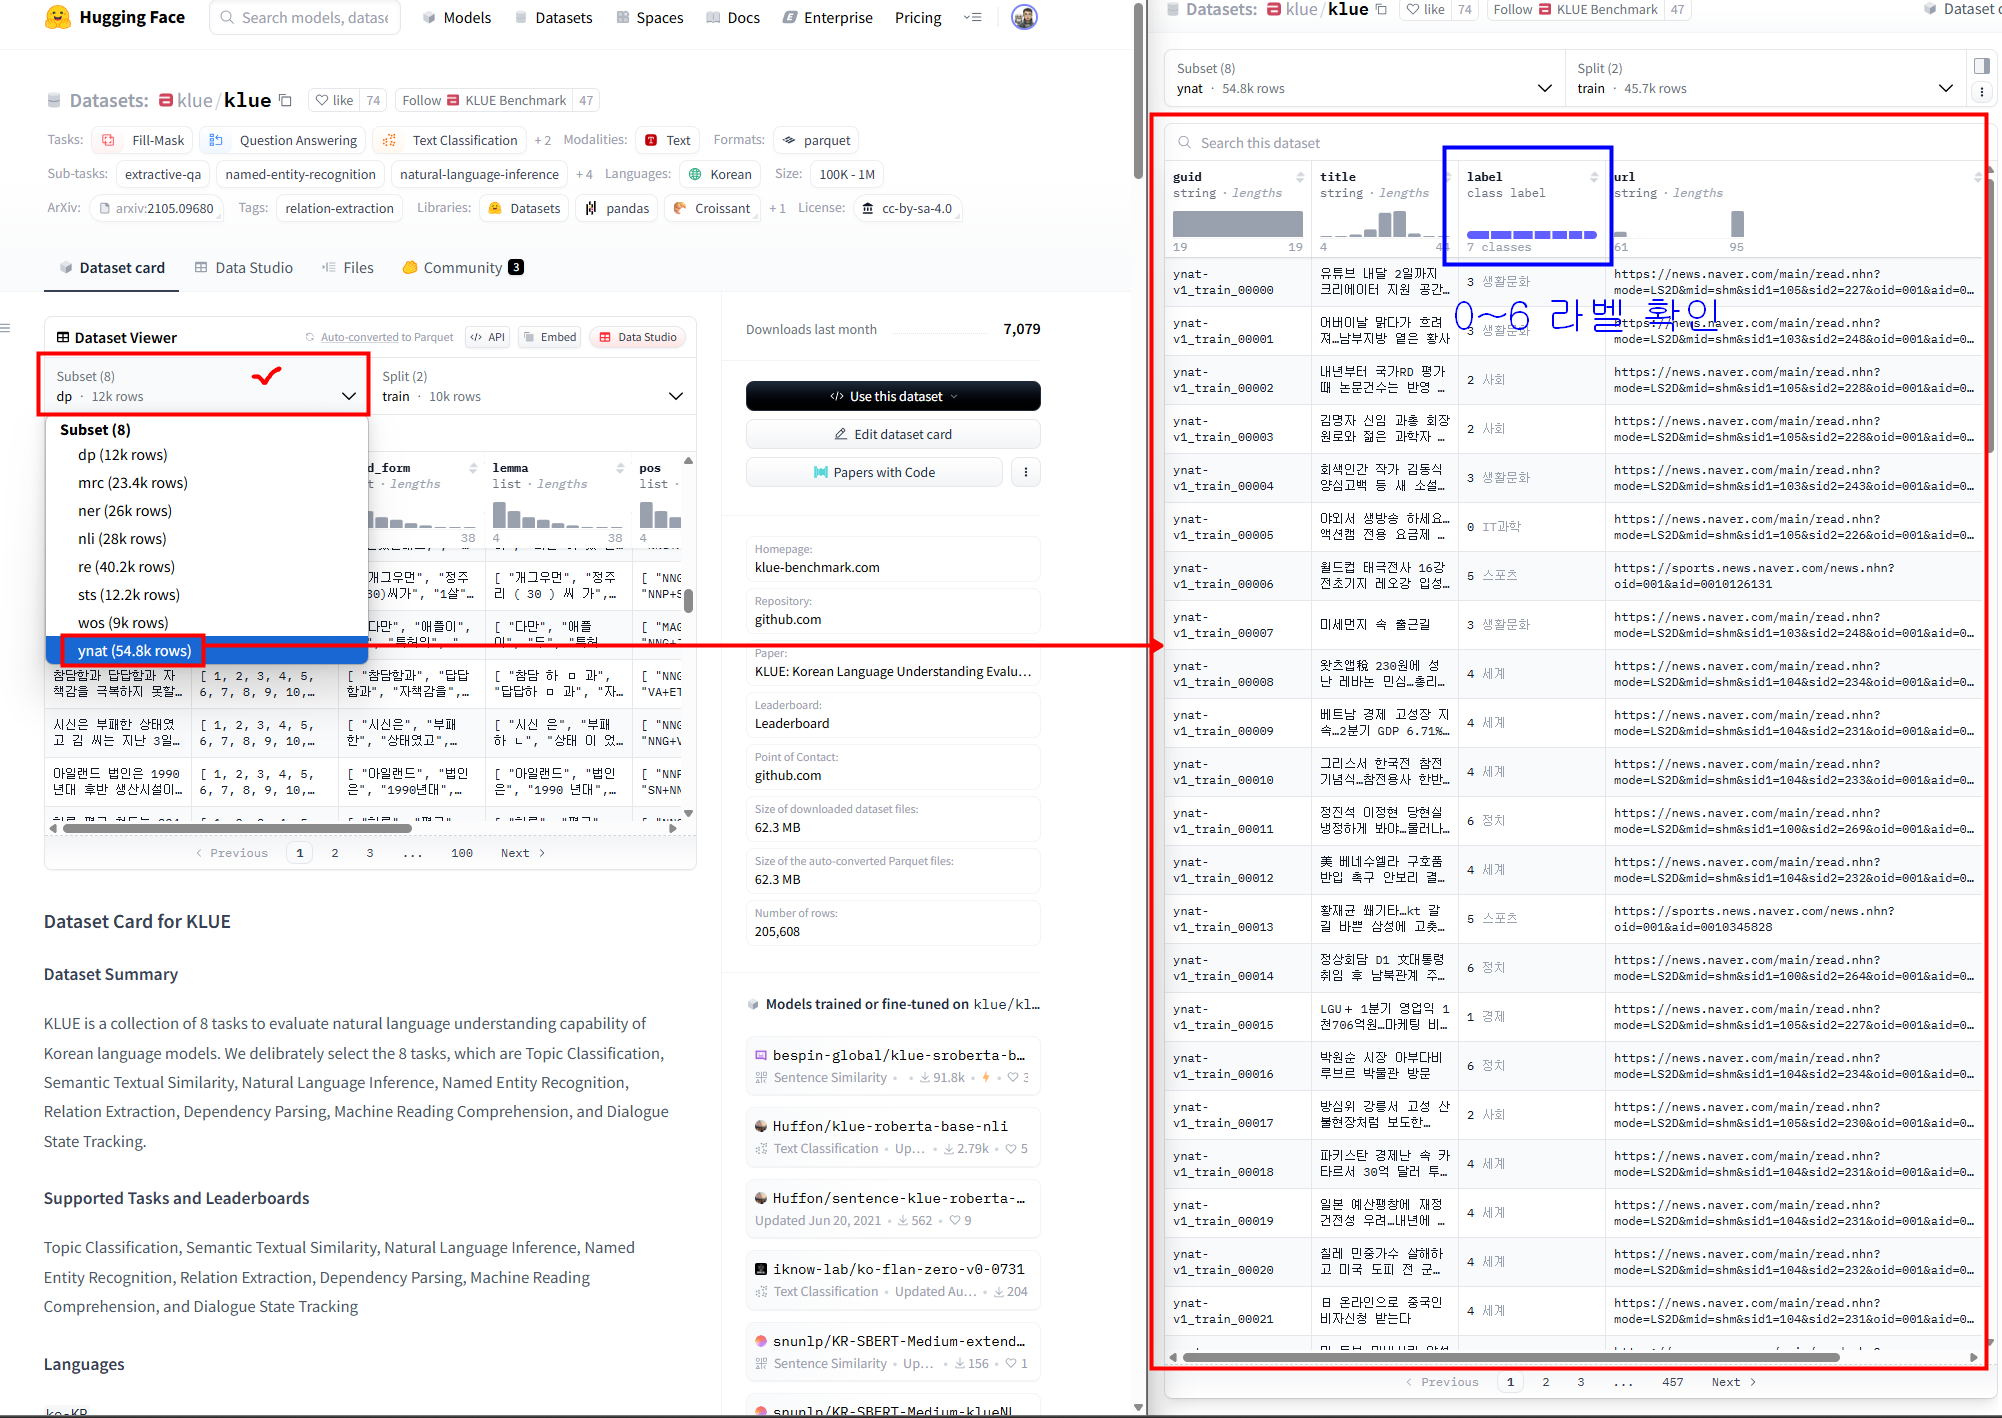

In [ ]:
# pandas의 데이터프레임으로 정리
raw_datasets['train'].to_pandas()

,guid,title,label,url,date
0,ynat-v1_train_00000,유튜브 내달 2일까지 크리에이터 지원 공간 운영,3,https://news.naver.com/main/read.nhn?mode=LS2D...,2016.06.30. 오전 10:36
1,ynat-v1_train_00001,어버이날 맑다가 흐려져…남부지방 옅은 황사,3,https://news.naver.com/main/read.nhn?mode=LS2D...,2016.05.08. 오전 5:25
2,ynat-v1_train_00002,내년부터 국가RD 평가 때 논문건수는 반영 않는다,2,https://news.naver.com/main/read.nhn?mode=LS2D...,2016.03.15. 오후 12:00
3,ynat-v1_train_00003,김명자 신임 과총 회장 원로와 젊은 과학자 지혜 모을 것,2,https://news.naver.com/main/read.nhn?mode=LS2D...,2017.02.28. 오전 9:54
4,ynat-v1_train_00004,회색인간 작가 김동식 양심고백 등 새 소설집 2권 출간,3,https://news.naver.com/main/read.nhn?mode=LS2D...,2018.04.03. 오전 7:05
...,...,...,...,...,...
45673,ynat-v1_train_45673,사우디 아람코 주요 석유시설·유전 드론 공격에 화재,4,https://news.naver.com/main/read.nhn?mode=LS2D...,2019.09.14. 오후 4:36
45674,ynat-v1_train_45674,박기원 감독 눈치 보지 말고…비예나 눈치 본 건 아닌데,5,https://sports.news.naver.com/news.nhn?oid=001...,2019.11.03 17:06
45675,ynat-v1_train_45675,아시안게임 첫 경기 앞둔 라건아 인도네시아 팬이라도 ...,5,https://sports.news.naver.com/news.nhn?oid=001...,2018.08.13 17:54
45676,ynat-v1_train_45676,트럼프 미중 무역협상 1단계 합의 서명식 가질 것종합,4,https://news.naver.com/main/read.nhn?mode=LS2D...,2019.12.25. 오후 4:36


- 필드 정보

| 필드명     | 필드 설명                                                                                               |
| ------- | --------------------------------------------------------------------------------------------------- |
| `guid`  | 데이터 고유 ID (예: `ynat-v1_train_00000`)                                                                |
| `title` | 기사 제목 (연합뉴스 헤드라인 텍스트)                                                                               |
| `label` | 토픽 분류 레이블 (정수형):<br>- 0: IT·과학<br>- 1: 경제<br>- 2: 사회<br>- 3: 생활문화<br>- 4: 세계<br>- 5: 스포츠<br>- 6: 정치 |
| `url`   | 원문 기사 링크 (네이버 뉴스 URL)                                                                               |
| `date`  | 기사 게시 일시 (예: `2016.06.30. 오전 10:36`)                                                                |


# Hugging Face_Fine-tuning 워크플로우

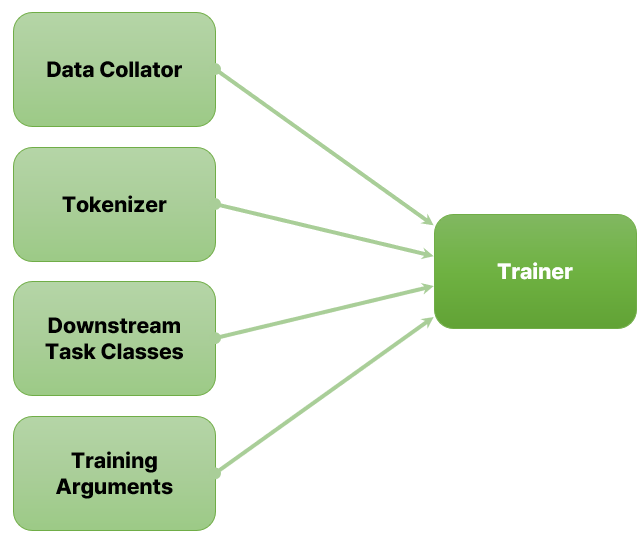

- **업스트림(UpStream)** : 모델이 일반적인 언어 패턴을 배우는 **<U>사전학습 과정**</U>
- **다운스트림(Downstream)** : 사전 학습 된 모델을 특정 작업에 맞게 조정하는 **<U>Fine-Tuning 과정**</U>

### 구성요소

> #### 1. **Trainer**
> - **<U>데이터 전처리부터 학습·평가·저장**</U>까지 모든 과정을 한 번에 수행해 주는 고수준 API
> - 아래 4가지 주요 구성 요소를 조합해 Fine-tuning 워크플로우를 완성시켜야 함

> #### 2. **DataCollator**
> - 데이터를 **<U>배치 단위로 묶어주는 클래스**</U>
> - 각 배치의 입력 데이터를 일정한 크기로 맞추기 위해 패딩 처리 등을 수행함

> #### 3. **Tokenizer**
> - 사전 학습 된 모델에 맞는 **<U>토큰화 도구**</U>
> - 업스트림 시 동일한 토크나이저를 사용해 입력 데이터를 처리함

> #### 4. **Downstream Task Classes**
> - **<U>Fine-tuning 대상 모델**</U>
> - 사전학습된 모델을 다양한 NLP 작업에 맞게 활용할 수 있음
```
예시)
    AutoModelForSequenceClassification (분류)
    AutoModelForQuestionAnswering (QA)
    AutoModelForTokenClassification (개체명 인식)
```

> #### 5. **Training Arguments**
> - 학습 과정에서 필요한 **하이퍼파라미터**들을 설정하는 클래스
> - **<U>학습률(learning rate), 배치 크기, 에포크 수(epochs) 등**</U> 학습 관련 설정값을 관리함







## 2. 토크나이저 로딩
- `KoELECTRA 모델로 실습 진행` : **<U>koelectra-base-v3-discriminator**</U> 활용

#### monologg/koelectra 주요 버전 및 종류

- GitHub : https://github.com/monologg/KoELECTRA/blob/master/README.md

| 모델 이름                                       | 크기    | 역할            | 설명                                                         |
| ------------------------------------------- | ----- | ------------- | ---------------------------------------------------------- |
| `monologg/koelectra-base-generator`         | Base  | Generator     | 토큰 생성기(generator) 역할 · v3 이전 버전         |
| `monologg/koelectra-base-discriminator`     | Base  | Discriminator | 토큰 판별기(discriminator) 역할 · v1/v2 기본 버전  |
| `monologg/koelectra-base-v3-generator`      | Base  | Generator     | v3 버전 · generator                       |
| `monologg/koelectra-base-v3-discriminator`  | Base  | Discriminator | v3 버전 · discriminator                   |
| `monologg/koelectra-small-generator`        | Small | Generator     | 소형 모델 · generator                       |
| `monologg/koelectra-small-discriminator`    | Small | Discriminator | 소형 모델 · discriminator                   |
| `monologg/koelectra-small-v3-generator`     | Small | Generator     | v3 소형 버전 · generator (NSMC 감성분석 등에 활용 가능)                  |
| `monologg/koelectra-small-v3-discriminator` | Small | Discriminator | v3 소형 버전 · discriminator (감정분석, 문장분류 등)                    |
| `monologg/koelectra-small-v3-goemotions`    | Small | Discriminator | v3 소형 버전 · GoEmotions 감정분류용 (영문 감정 레이블 매핑)                 |
| `monologg/koelectra-base-v3-naver-ner`      | Base  | Discriminator | v3 버전 · Naver NER(개체명 인식)용 fine-tuned 모델                   |
| `monologg/koelectra-base-v3-gender-bias`    | Base  | Discriminator | v3 버전 · 성별 편향 분석용 (gender-bias) 모델                         |

In [ ]:
# 사전학습된 모델에 맞는 토크나이저를 자동으로 판단해서 불러오겠다!
from transformers import AutoTokenizer

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
model_name = 'monologg/koelectra-base-v3-discriminator'

In [ ]:
# 사전 학습된 토크나이저 다운로드
tokenizer = AutoTokenizer.from_pretrained(
    model_name, # 무슨 모델을 가져오는지 설정
    clean_up_tokenization_sapce = True # 토큰화 이후 공백문자 등 불필요한 내용 정리하는 옵션
)

tokenizer_config.json:   0%|          | 0.00/61.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
# 테스트용 데이터 활용해서 토큰화 진행해보기
raw_datasets["train"][0]['title']

'유튜브 내달 2일까지 크리에이터 지원 공간 운영'

In [ ]:
# 한개 문장을 토큰화 시켜서 결과를 확인해보자
temp_result = tokenizer(
    raw_datasets["train"][0]['title'],  # 문장데이터
    truncation = True,  # 최대 토큰 길이를 넘으면 잘라주세요.
    max_length = 128  # 토큰의 최대길이 (뉴스제목은 대게 짧기 때문에 128, 상황에 따라 조정)
# return_tensors = "pt" -> 파이토치의 텐서라는 자료형으로 반환해주세요.
#                  "tf" -> 텐서플로우의 텐서라는 자료형으로 반환해주세요
#                  "np" -> 넘파이의 배열이라는 자료형으로 반환해주세요
# 보통 Trainer나 DataCollactor 에서 배치 텐서로 변환시키는 경우가 많다.
)

temp_result
#'input_ids' : 토큰 ID 리스트 (정수로 바뀐단어)
#'token_type_ids' : 구분된 id 리스트(무슨 문장에 토큰이 들어가있나?) -> 단일문장에서는 모두 0
# 'attention_mask' : 실제 토큰(1)인지 / 패딩으로 채워진 토큰(0)인지 구분

# 특수 토큰 목록 (koElectra) 기준
# 0 : [pad] - Padding : 문장의 길이를 맞추기 위한 빈 공간
# 1 : [UNK] - unknown : 단어사전에 없는 단어를 처리 할 때 사용
# 2 : [CLS] - Classification : 문장의 시작점에 배치되는 토큰
# 3 : [SEP] - Seperator : 문장과 문장을 구분하는 토큰 / 끝을 알리는 토큰
# 4 : [MASK] - 사전 학습 단계에서 사용 /  특정 단어를 가렸음을 알리는 토큰

{'input_ids': [2, 11468, 11642, 22, 4366, 4149, 4200, 32462, 6310, 6800, 6411, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
# 토큰 목록 확인
tokenizer.convert_ids_to_tokens(temp_result['input_ids'])

# 우리가 사용하는 대부분의 토크나이저는 word piece 기반의 모델 -> 단어 조각을 모아서 사용
# 서브 워드를 활용하자. -> 단어를 파편화 시켜뒀다 필요 할 때 조합해서 쓰자
# ##의 의미 : 앞에 있는 단어와 연결되는 구조

['[CLS]',
 '유튜브',
 '내달',
 '2',
 '##일',
 '##까',
 '##지',
 '크리에이터',
 '지원',
 '공간',
 '운영',
 '[SEP]']

In [ ]:
# 토크나이저를 함수로 정의하자
def tokenize_function(example) :
    return tokenizer(
        example['title'],
        truncation=True,
        max_length=128
        )

### 데이터에 토크나이저를 적용하기 위한 함수 종류

> #### **map()**
> - **<U>변환을 즉시 적용**</U>하며, 변환된 결과는 새로운 데이터셋으로 반환됨
> - 토큰화, 라벨 변환 등 데이터 전처리 작업에서 자주 사용

> #### **with_transform()**
> - 변환을 등록해 두고, 실제 **<U>데이터 접근 시 변환을 적용**</U>함 (스트림형)
> - 학습을 수행할 때 호출하여 변형이 이루어짐
> - 메모리 절약을 위해, 또는 데이터셋을 한 번에 모두 변형할 필요가 없을 때 유용

In [ ]:
# 데이터셋에 토크나이저 적용 (학습/검증셋 모두 변환)
tokenized_datasets = raw_datasets.map(
    tokenize_function, # 전처리 함수 이름
    # 동작 방식 설정 : 예시 하나가 아니라 여러개씩 모아서 토큰화 함수에 전달하겠다.
    batched = True # 속도 향샹 / padding, truncation 옵션 적용시 일괄 처리에 적합
)

Map:   0%|          | 0/45678 [00:00<?, ? examples/s]

Map:   0%|          | 0/9107 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets
# 기존 데이터에서 'input_ids', 'token_type_ids', 'attention_mask'가 추가된 것을 확인 할 수 있음.

DatasetDict({
    train: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45678
    })
    validation: Dataset({
        features: ['guid', 'title', 'label', 'url', 'date', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9107
    })
})

In [ ]:
# 특성 필드 살펴보기
tokenized_datasets['train'].features

{'guid': Value('string'),
 'title': Value('string'),
 'label': ClassLabel(names=['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']),
 'url': Value('string'),
 'date': Value('string'),
 'input_ids': List(Value('int32')),
 'token_type_ids': List(Value('int8')),
 'attention_mask': List(Value('int8'))}

In [ ]:
# 원본에서 불필요한 컬럼을 삭제해보자
# 이때 label 은 학습시 필요하므로 제외
remove_columns = [key for key in raw_datasets["train"].features.keys() if key != 'label']
remove_columns

['guid', 'title', 'url', 'date']

In [ ]:
# 훈련에 필요없는 컬럼을 제거
tokenized_datasets = tokenized_datasets.remove_columns(remove_columns)

In [ ]:
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 45678
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 9107
    })
})

## 3. 모델 불러오기
- Downstream Task Classes 로드 (사전학습 모델을 불러오기)
- 해석하기 쉽게 모델 설정에서 레이블 이름도 등록해두자!

In [ ]:
# 이미 label 컬럼은 메타 정보로 클래스 이름이 들어 있으므로, 레이블명 추출 진행 - 인덱스 순서
label_names = raw_datasets['train'].features['label'].names
label_names

['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

In [ ]:
# id2label / label2id 매핑 자동 생성
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name:i for i, name in enumerate(label_names)}

In [ ]:
id2label, label2id

({0: 'IT과학', 1: '경제', 2: '사회', 3: '생활문화', 4: '세계', 5: '스포츠', 6: '정치'},
 {'IT과학': 0, '경제': 1, '사회': 2, '생활문화': 3, '세계': 4, '스포츠': 5, '정치': 6})

In [ ]:
# 모델 설정
from transformers import AutoModelForSequenceClassification

# AutoModelForSequenceClassification : 분류
# AutoModelForQuestionAnswering : 질의 응답
# AutoModelForTokenClassification : 토큰 분류(개체명 인식) 등

In [ ]:
# 사전학습 모델 로드
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, # koelectra 모델 가져오기
    num_labels = len(label_names) # 분류할 정답의 갯수
)

# 아래의 경고 내용
# 현재 사전학습된 상태 -> 전이학습 X : 전이학습을 진행해야 예측과 추론이 가능하다.

pytorch_model.bin:   0%|          | 0.00/452M [00:00<?, ?B/s]

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at monologg/koelectra-base-v3-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 모델이 가지고 있는 정답 정보를 살펴보기
model.config.id2label, model.config.label2id

({0: 'LABEL_0',
  1: 'LABEL_1',
  2: 'LABEL_2',
  3: 'LABEL_3',
  4: 'LABEL_4',
  5: 'LABEL_5',
  6: 'LABEL_6'},
 {'LABEL_0': 0,
  'LABEL_1': 1,
  'LABEL_2': 2,
  'LABEL_3': 3,
  'LABEL_4': 4,
  'LABEL_5': 5,
  'LABEL_6': 6})

In [ ]:
model.config.id2label = id2label
model.config.label2id = label2id

In [ ]:
# 모델에게 우리가 가지고 있는 정답을 알려줌
model.config.id2label, model.config.label2id

({0: 'IT과학', 1: '경제', 2: '사회', 3: '생활문화', 4: '세계', 5: '스포츠', 6: '정치'},
 {'IT과학': 0, '경제': 1, '사회': 2, '생활문화': 3, '세계': 4, '스포츠': 5, '정치': 6})

## 4. Data Collator & 평가지표함수 정의

> **Collator**
> - Trainer에게 전달해주는 클래스
> - 이때, Transformer 모델 입력은 길이가 다를 수 있는 시퀀스이므로, 한 배치 내 최대 길이에 맞추어 패딩이 필요

> **평가지표 함수**
> - 학습 중 검증 단계에서 계산할 평가지표 함수 정의
> - 정확도, 정밀도, 재현율, F1 활용해보기

In [ ]:
# 동적으로 배치 내 최장길이(128)에 맞춰서 패딩을 진행하고 Trainer에게 데이터를 전달
from transformers import DataCollatorWithPadding

In [ ]:
# Collator 초기화
data_collator = DataCollatorWithPadding(tokenizer = tokenizer)

```python
# tokenizer 지정 이유
tokenizer가 가진
- pad_token_id(패딩 토크번호)
- padding_side(패딩을 어느쪽에 채우는지)
- model_max_length(최대 입력 길이) 등
패딩 기준 정보 제공을 위함
```

#### 평가지표 함수 정의 하기 전, validation set을 활용하여 Test

- 1) 예측에 사용할 모델 입력 만들기

In [ ]:
# 현재 생성된 모델을 사용하기 위해 cuda 환경에 셋팅해 두겠다.
model = model.to(device)

In [ ]:
# 검증셋에서 샘플 가져오기
sample = tokenized_datasets['validation'][0]
print(sample)

{'label': 2, 'input_ids': [2, 25, 4639, 4005, 23362, 18075, 4034, 2411, 4219, 27, 4156, 4172, 4005, 6874, 4164, 4034, 3081, 4880, 4176, 3], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
# 모델에 입력으로 전달하기 위해 데이터 변환작업을 진행
# 정답을 제외한 다른 데이터들을 뽑아와서 Tensor로 변환한 다음 모델이 있는 GPU로 이동 시키겠다.
use_columns = [key for key in tokenized_datasets['validation'].features.keys() if key != 'label']
use_columns

# 컴프리핸션 -> for 반복문
# use_columns = []
# for key in tokenized_datasets['validation'].features.keys() :
#   if key != 'label' :
#     use_columns.append(key)

['input_ids', 'token_type_ids', 'attention_mask']

In [ ]:
# 딕셔너리 형태로 모델의 입력값을 담아두자
inputs = {}

# sample 변수 순회
for key, value in sample.items() : # sample dict의 키와 value를 모두 돌아보겠다.
    if key in use_columns : # 순회한 키 값이 use_columns 안에 들어있다면
        tensor = torch.tensor(value) # Transformer 모델은 입력이 Tensor로 만들어져야 읽을 수 있음.
        tensor = tensor.unsqueeze(0) # unsqeeze -> 배치 차원을 추가하는 함수 / 모델은 배치 단위로 입력을 받는다.
                                    # 이 때 데이터의 형태를 보면 [seq_len]만 존재
                                    # unsqueeze() 함수를 사용 했을때 [batch_size, seq_len] 형태로 변경
        tensor = tensor.to(device) # 앞서 확인한 device로 이동하겠다. (데이터를 gpu로 보내겠다.)

        # 딕셔너리 추가
        inputs[key] = tensor

inputs
# 기존의 값들이 transformer 모델이 읽을 수 있는 tensor 로 변경

{'input_ids': tensor([[    2,    25,  4639,  4005, 23362, 18075,  4034,  2411,  4219,    27,
           4156,  4172,  4005,  6874,  4164,  4034,  3081,  4880,  4176,     3]],
        device='cuda:0'),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]],
        device='cuda:0'),
 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]],
        device='cuda:0')}

In [ ]:
# 정답 레이블도 같은 방식으로 텐서 변환후 GPU로 이동
labels = sample['label']
label_tensor = torch.tensor([labels])
label_tensor = label_tensor.to(device)
label_tensor

# => 모델, 문제, 정답 모두 GPU로 넘겨주었다.

tensor([2], device='cuda:0')

In [ ]:
# 모델 예측
# 추론시 기울기 계산 필요 없다 -> 기울기 계산 비활성화
with torch.no_grad() : # 기울기 계산 비활성화
  outputs = model(**inputs) # 모델 입력 전달 후 예측값 할당
                            # ** 딕셔너리 형태로 전환, 한 덩어리의 데이터로 묶어서 처리해라.

In [ ]:
outputs
# logits : 평가지표 계산전에 원시점수(가공되지 않은 확신의 강도) - 확률 변환 전의 정답 예측 점수
# => 모두 음수로 나온 경우 0에 가장 가까운값이 최종 예측값
# => 양수 & 음수로 나온 경우 가장 큰 양수가 최종 예측값

SequenceClassifierOutput(loss=None, logits=tensor([[ 0.0486,  0.0207,  0.0010, -0.0732, -0.1484,  0.0879,  0.0563]],
       device='cuda:0'), hidden_states=None, attentions=None)

- 2) 평가지표 활용

In [ ]:
# 평가지표는 sklearn을 활용
import numpy as np

In [ ]:
# 원시점수 값을 CPU로 가져와서 Numpy 배열로 변환
logits = outputs.logits.cpu().numpy()
logits
# tensor 가 array로 변환

array([[ 0.04862124,  0.02067323,  0.00099826, -0.07324208, -0.14841992,
         0.08788577,  0.05628251]], dtype=float32)

In [ ]:
# 예측과 실제 비교
pred = np.argmax(logits) # 최대값의 인덱스(예측 라벨)을 뽑아보자
print(f'예측값 : {pred} >>> {model.config.id2label[pred]}')
print(f'실제값 : {labels} >>> {model.config.id2label[labels]}')

예측값 : 5 >>> 스포츠
실제값 : 2 >>> 사회


In [ ]:
# sklearn 평가지표 불러오기
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# precision_recall_fscore_support : 정밀도 / 재현율 / F1-Score 샘플을 한번에 계산해서 반환

In [ ]:
# labels 를 CPU로 가져와서 Numpy 배열 반환
labels = label_tensor.cpu().numpy()
labels

array([2])

In [ ]:
# 단일 예측값을 1차원 array로 변환
preds = np.array([pred])
preds

array([5])

In [ ]:
# 정확도 계산
acc = accuracy_score(labels, preds)
acc
# 출력
# -> 0.0 답이 맞지 않는다.
# -> 정확도 하나만 보는것은 의미가 없다. 과대적합, 데이터가 편차가 있을때 등등 정확도가 떨어진다.

0.0

In [ ]:
# 정밀도, 재현율, F1-score 계산
# _ : 의미없는 변수, 불필요한 값(support)에 대한 변수, support라는 값을 사용하지 않겠다.
#    네번째 반환값 (support : 각 클래스별 표본 수) 사용 X
prec, rec, f1 , _ = precision_recall_fscore_support(
    labels,            # 실제정답
    preds,             # 예측값
    average = "macro", # 각 클래스별 결과 (정밀도, 재현율, f1)를 계산한 뒤 모든 클래스를 동일한 비중으로 처리
                       # macro 는 정답의 갯수가 편차가 있을때 이를 계산해서 각 정답별 성능을 동일하게 평가
    zero_division = 0  # 분모가 0이 되는경우 (예측 / 실제 샘플이 없을때) 결과를 0으로 처리 하겠다.
)

prec, rec, f1 , _

(0.0, 0.0, 0.0, None)

### Trainer에게 전달할 평가지표 함수 정의

In [ ]:
def compute_metrics(eval_pred) :
  '''
  Trainer가 사용하는 평가지표 함수
  - eval_pred : (logits, labels) 튜플
  '''
  logits, labels = eval_pred
  preds = np.argmax(logits, axis = 1) # axis = 1 / 각 뉴스 제목별로 가로방향으로 비교 (어떤 라벨이 가장 큰값을 가지는지)
                                      # 결과는 (batch_size, ) 1차원의 배열 형태로 각 샘플별 예측 정답 들어있다.
  # 정확도
  acc = accuracy_score(labels, preds)

  # 정밀도, 재현율, F1 score계산
  prec, rec, f1 , _ = precision_recall_fscore_support(
    labels,            # 실제정답
    preds,             # 예측값
    average = "macro", # 각 클래스별 결과 (정밀도, 재현율, f1)를 계산한 뒤 모든 클래스를 동일한 비중으로 처리
                       # macro 는 정답의 갯수가 편차가 있을때 이를 계산해서 각 정답별 성능을 동일하게 평가
    zero_division = 0)  # 분모가 0이 되는경우 (예측 / 실제 샘플이 없을때) 결과를 0으로 처리 하겠다.

  return {'accuracy' : acc, 'precision' : prec, 'recall' : rec, 'f1' : f1}

## 5. Training Arguments 설정

In [ ]:
# 모델이 한번의 학습과정에서 처리할 데이터 수
batch_size = 64

# batch 사이즈를 크게주는 경우 더 많은 데이터를 한번에 처리하기 때문에 업데이트 횟수는 줄어든다.
# 그러나 메모리 사용량이 증가한다.
# batch 사이즈를 작게주는 경우 더 자주 업데이트하지만
# 하나의 배치에서 계산된 손실값이 불안정 할 수 있음

# => batch 사이즈를 크게 주는경우와 적게 줘야 하는경우가 있음
# 데이터 깔끔 -> 배치사이즈 크게 / 데이터 지저분 -> 배치사이즈 작게

In [ ]:
import os
from transformers import TrainingArguments

In [ ]:
# 학습에 필요한 하이퍼파라미터 및 설정
training_args = TrainingArguments(
    output_dir = "./data/ynat-model",         # 학습 결과(모델 가중치, 체크포인트 등)을 저장할 디렉토리
    num_train_epochs = 3,                     # 학습할 에포크(Epoch) 수, 전체 데이터셋을 몇 번 반복하여 학습할지를 설정함
    per_device_train_batch_size = batch_size, # 학습 시 사용될 배치 크기
    per_device_eval_batch_size = batch_size,  # 검증 시 배치 크기
    learning_rate = 5e-5,                     # 학습률 (5e-5=0.00005 : BERT계열 모델에 흔히 쓰이는 값)
    eval_strategy = "epoch",                  # 이벨류에이션 스트레이트지(검증 전략), "epoch"로 하면 각 epoch 끝날 때 검증
    logging_steps = 50,                       # 학습 중간에 로그를 찍는 간격 (스텝 수)
    save_strategy = "epoch",                  # 모델 저장 전략 (여기서는 epoch마다 저장)
    load_best_model_at_end = True,            # True : 검증 성능이 최고인 체크포인트를 마지막에 불러옴
    metric_for_best_model = "accuracy",       # 최고 모델 판단에 사용할 평가지표 ("accuracy"으로 지정)
    push_to_hub = False,                      # 학습 후 Hugging Face Hub에 자동 업로드 하지 않겠다.
    report_to = 'none',                       # W&B 비활성화 (W&B 연동 시, 로그를 남기기 위해 API 키 인증을 요구하므로 none 설정)
                                              # 24년 10월 경부터 Trainer에 기본값으로 W&B(Weights & Biases)에 실험(run)을 기록하도록 설정되어 있음
    save_safetensors = False                  # (추가) safetensors 저장시 발생하는 오류를 회피하기 위해 False로 설정 (4/28 시작)

)

- 학습 시 W&B 연동 요구 화면

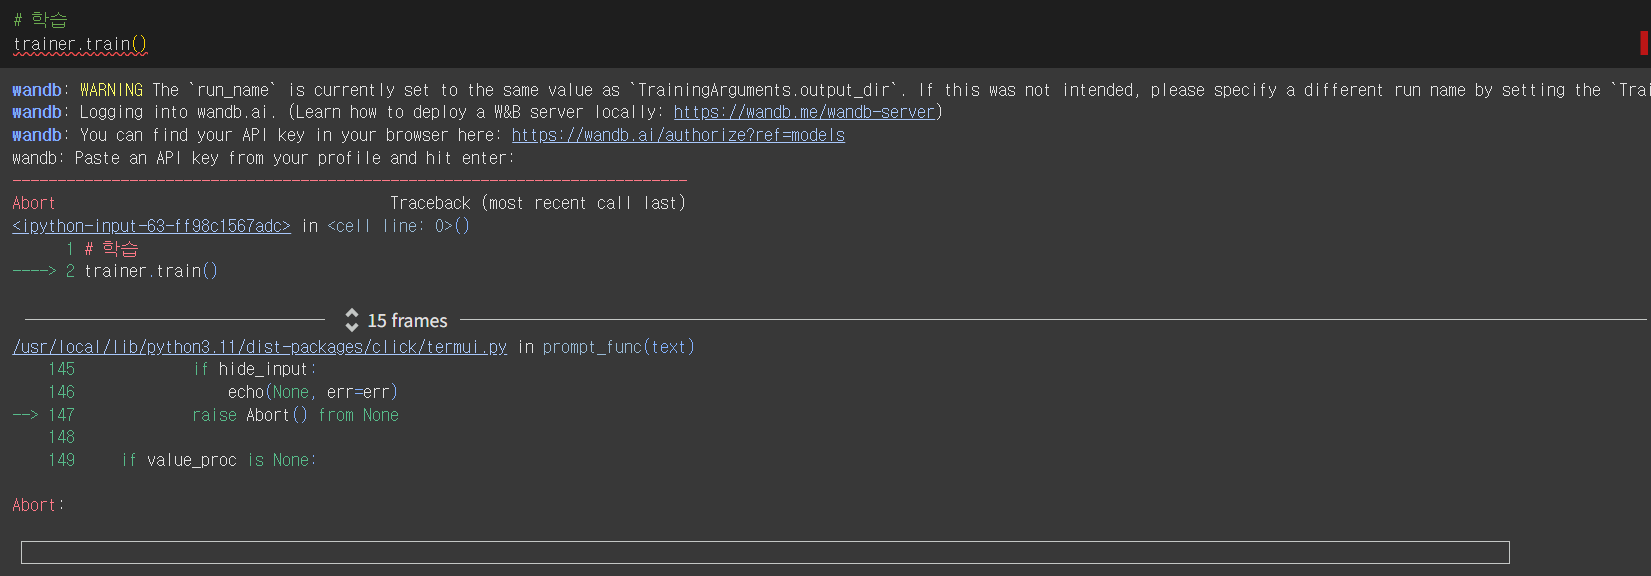

## 6-1. Trainer 초기화 & Fine-Tuning
- Trainer 클래스 : 모델 훈련을 간소화해주는 고수준 API
- Training Arguments, 모델, 데이터셋, 데이터 콜레이터, 평가 함수 등을 인자로 받아 내부에서 학습 루프를 관리

In [ ]:
from transformers import Trainer

In [ ]:
# 학습 객체 생성
trainer = Trainer(
    model = model, # 다운 스트림 테스크 클래스
    args = training_args, # 트레이닝 Arguments
    train_dataset = tokenized_datasets['train'], # 학습용 데이터
    eval_dataset = tokenized_datasets['validation'], # 검증용 데이터
    data_collator = data_collator, # 데이터 콜레이터
    tokenizer = tokenizer, # 토크나이저
    compute_metrics = compute_metrics # 평가 함수
)

In [ ]:
# 학습 (T4 GPU / batch_size 64 로 약 12분 소요)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.184800,0.498500,0.851213,0.843913,0.865025,0.852415
2,0.139300,0.526837,0.853080,0.842802,0.863547,0.851927
3,0.117800,0.595211,0.854837,0.845137,0.864695,0.854311


TrainOutput(global_step=2142, training_loss=0.14491347694486018, metrics={'train_runtime': 805.4985, 'train_samples_per_second': 170.123, 'train_steps_per_second': 2.659, 'total_flos': 1616745095802300.0, 'train_loss': 0.14491347694486018, 'epoch': 3.0})

```python
# [2142/2142 11:10, Epoch 3/3]
# └─ 현재까지 진행된 스텝(step)/총 스텝(step), 현재 시각, 현재 Epoch/총 Epoch

Epoch   Training Loss   Validation Loss   Accuracy    Precision   Recall      F1
1       0.388600        0.435725          0.848578    0.838680    0.865160    0.849954
# └─ 각 컬럼 설명:
#    Epoch             : 학습 라운드 번호 (1번째 Epoch 수행 결과)
#    Training Loss     : 학습 데이터셋에서 계산된 평균 손실값
#    Validation Loss   : 검증 데이터셋에서 계산된 평균 손실값
#    Accuracy          : 검증셋에서 예측 정확도 (전체 정답률)
#    Precision         : 검증셋에서 정밀도(Positive 예측 중 정답 비율)
#    Recall            : 검증셋에서 재현율(실제 Positive 중 맞춘 비율)
#    F1                : 정밀도와 재현율의 조화평균

2       0.297100        0.401831          0.858351    0.851668    0.869896    0.859527
3       0.219600        0.428563          0.859449    0.851009    0.873556    0.861469

# TrainOutput(...)
TrainOutput(
    global_step=2142,                # 전체 학습 스텝 수
    training_loss=0.3618691268087435,# 전체 학습 과정의 평균 손실
    metrics={                        # 추가 학습 메트릭
        'train_runtime': 670.7718,           # 학습에 걸린 총 시간(초)
        'train_samples_per_second': 204.293, # 초당 처리한 샘플 수
        'train_steps_per_second': 3.193,     # 초당 수행한 학습 스텝 수
        'total_flos': 1616745095802300.0,    # 학습에 사용된 총 부동소수점 연산량
        'train_loss': 0.3618691268087435,    # TrainOutput에 기록된 최종 train loss
        'epoch': 3.0                         # 완료된 Epoch 수
    }
)
```

## 6-2. 모델 평가 및 성능 분석
- 검증 데이터에 대한 최종 성능을 확인과 함께 혼돈행렬 관측
- `trainer.predict`로 개별 예측도 가능

In [ ]:
# 검증셋에 대한 최종평가
metrics = trainer.evaluate() # 성능평가 진행
metrics

# 'eval_loss': 0.595210611820221  >> 검증셋트 평균 손실값
# 'eval_accuracy': 0.854836938618645 >> 검증셋트 정확도
# 'eval_precision': 0.8451369313315181  >>검증셋트 정밀도
# 'eval_recall': 0.8646951979383003 >> 검증셋트 재현율
# 'eval_f1': 0.8543110119783686 >> 검증셋트 F1-Score
# 'eval_runtime': 14.3719 >> 평가시간
# 'eval_samples_per_second': 633.667  >> 초당 처리 샘플 수
# 'eval_steps_per_second': 9.95 >> 초당 처리 스텝수
# 'epoch': 3.0  >> 수행된 에포크 수

{'eval_loss': 0.595210611820221,
 'eval_accuracy': 0.854836938618645,
 'eval_precision': 0.8451369313315181,
 'eval_recall': 0.8646951979383003,
 'eval_f1': 0.8543110119783686,
 'eval_runtime': 14.3719,
 'eval_samples_per_second': 633.667,
 'eval_steps_per_second': 9.95,
 'epoch': 3.0}

**혼동 행렬(Confusion Matrix)**을 통해 어떤 주제에서 오분류가 발생하는지 관측

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# 검증 셋으로 예측 수행
pred_results = trainer.predict(tokenized_datasets['validation'])
pred_results

PredictionOutput(predictions=array([[-1.5973755 ,  7.358803  ,  1.5158198 , ..., -2.4332292 ,
        -2.9011552 , -3.2006488 ],
       [ 2.332879  , -0.09047637,  6.4065747 , ..., -3.7792845 ,
        -3.9529877 , -2.2353876 ],
       [ 6.674956  , -0.70520747, -0.27522486, ..., -1.8872473 ,
        -2.020198  , -2.5473132 ],
       ...,
       [-2.6573148 ,  7.1796722 ,  1.1537838 , ..., -2.3100748 ,
        -2.6875865 , -3.0167818 ],
       [-2.5947733 , -2.1555917 ,  7.09616   , ..., -2.803704  ,
        -3.8231044 ,  1.9285138 ],
       [-1.61303   , -2.2117279 ,  7.1599317 , ..., -3.2854557 ,
        -2.7408237 , -2.3529317 ]], dtype=float32), label_ids=array([2, 2, 0, ..., 1, 2, 2]), metrics={'test_loss': 0.595210611820221, 'test_accuracy': 0.854836938618645, 'test_precision': 0.8451369313315181, 'test_recall': 0.8646951979383003, 'test_f1': 0.8543110119783686, 'test_runtime': 13.4716, 'test_samples_per_second': 676.016, 'test_steps_per_second': 10.615})

In [ ]:
# 실제 정답 추출
y_true = pred_results.label_ids
y_true

array([2, 2, 0, ..., 1, 2, 2])

In [ ]:
# 예측 레이블 생성
y_pred = np.argmax(pred_results.predictions, axis = 1)
y_pred

array([1, 2, 0, ..., 1, 2, 2])

In [ ]:
# 혼동행렬 생성
cm = confusion_matrix(y_true, y_pred)
cm

array([[ 449,   38,   48,    8,    6,    5,    0],
       [  30, 1166,  126,    9,   11,    4,    2],
       [  78,  215, 3107,  152,   31,   26,   92],
       [  24,   23,  124, 1159,   22,   12,    5],
       [   9,   14,   18,   26,  740,   15,   13],
       [   0,    1,    5,    2,   10,  559,    1],
       [   0,    6,   87,    4,   15,    5,  605]])

- 시각화로 혼돈행렬 관측

한글 폰트는 나눔고딕 설치 대신 ```GULIM.TTC 폰트 공유```

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import os

# 폰트 경로 설정
font_path = './data/GULIM.TTC'
font_prop = fm.FontProperties(fname = font_path).get_name()

# 파일 존재 확인 및 등록
if os.path.exists(font_path) : # 만약 해당하는 경로에 파일이 존재 한다면
  # matplotlib에 폰트 추가
  fm.fontManager.addfont(font_path)
  # 추가된 폰트의 이름 추출
  font_name = fm.FontProperties(fname=font_path).get_name()

  # 기본 폰트 설정
  plt.rc('font', family = font_name)
  plt.rc('axes', unicode_minus = False)
  print(f"성공 : {font_name} 폰트가 설정 되었음")

else :
  print(f"실패 : {font_path}에 파일이 없습니다. 폴더 위치 확인해주세요.")

성공 : Gulim 폰트가 설정 되었음


In [ ]:
# 레이블 이름 리스트 설정
label_names = list(model.config.label2id.keys())
label_names

['IT과학', '경제', '사회', '생활문화', '세계', '스포츠', '정치']

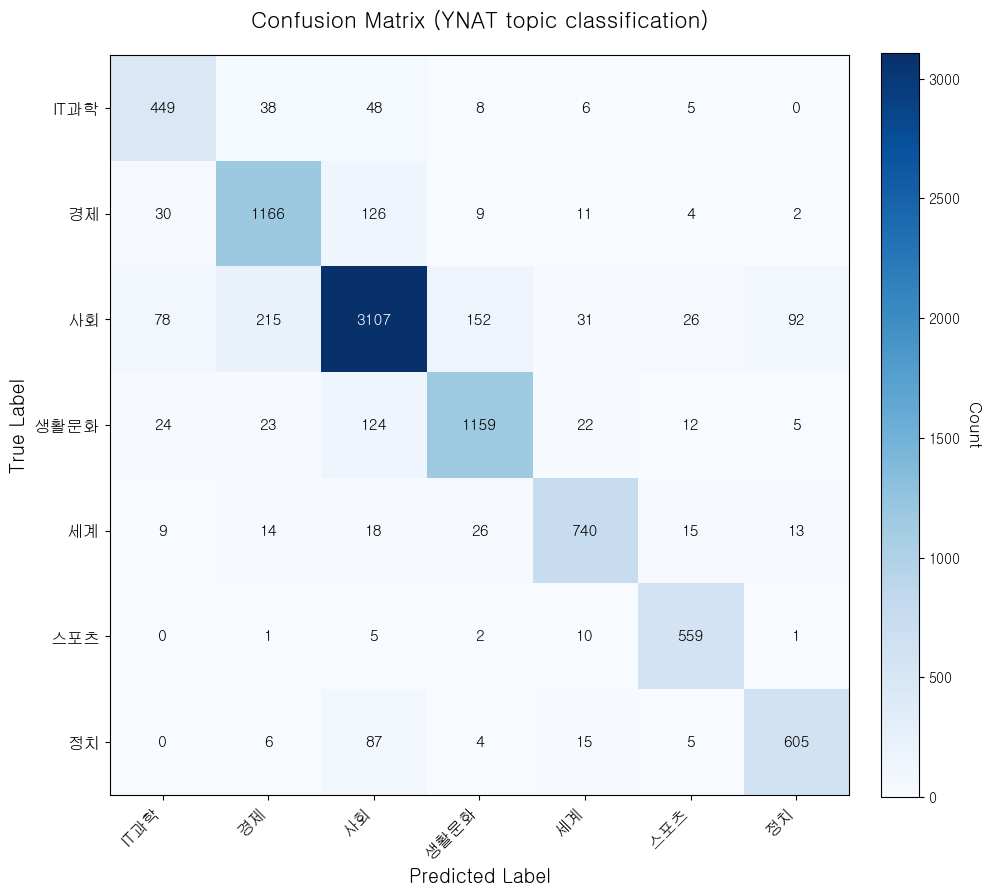

In [ ]:
# Figure & Axes(그래프 그릴 영역) 생성
fig, ax = plt.subplots(figsize=(10, 10)) # 전체 그림 크기를 10×10인치로 지정

# 혼동행렬 시각화
# ax.imshow: 2D 배열(혼돈행렬)을 컬러맵으로 시각화
im = ax.imshow(cm, cmap='Blues') # 파란색 계열 색상표 사용

# 컬러바 추가
cbar = fig.colorbar(
    im,               # 시각화된 이미지 객체
    ax = ax,          # 컬러바를 붙일 Axes 지정
    fraction = 0.046, # 컬러바 너비 조절
    pad = 0.04        # 컬러바 간격 조절
)

# 컬러바 축의 레이블 설정
cbar.ax.set_ylabel(
    'Count',        # 레이블 텍스트
    rotation = -90, # 레이블 세로 방향으로 회전
    va = "bottom",  # 수직 정렬을 아래쪽으로
    fontsize = 12   # 글자 크기
)

# 눈금 위치 및 레이블 설정
n = len(label_names)                # 레이블 개수
ax.set_xticks(np.arange(n)) # 눈금(tick) 위치를 0..n-1로 지정
ax.set_yticks(np.arange(n)) # 눈금(tick) 위치를 0..n-1로 지정

# 눈금에 표시할 텍스트 지정
ax.set_xticklabels(label_names, rotation = 45, ha = "right", fontsize = 12) # X축 레이블 45도 회전, 수평 정렬을 오른쪽으로, 글자 크기 12
ax.set_yticklabels(label_names, fontsize = 12)

# 축 제목 및 메인 타이틀
ax.set_xlabel("Predicted Label", fontsize=14)
ax.set_ylabel("True Label", fontsize=14)
ax.set_title("Confusion Matrix (YNAT topic classification)", fontsize = 16, pad = 20) # 전체 그래프 제목 설정
                                                                                      # pad : 제목과 그래프 사이 여백(px)

# 각 셀에 값 표시
threshold = cm.max() / 2                                     # 셀 색 대비가 어두운지 밝은지 판단 기준
for i in range(n):
    for j in range(n):
        color = "white" if cm[i, j] > threshold else "black" # 셀 값이 threshold 이상이면 흰색 텍스트, 아니면 검정색
        ax.text(j, i, cm[i, j], ha = "center", va = "center", color = color, fontsize = 11) # ha, va: 수평·수직 정렬 방식

# 레이아웃 자동 조정 & 출력
plt.tight_layout() # 여백을 자동으로 조절해 레이블 겹침 방지
plt.show()

> **전반적 성능**
> - `eval_accuracy` ≈ 0.90로, 전체 샘플 중 약 90%를 올바르게 분류
> - Macro-averaged F1 ≈ 0.90로, 클래스 불균형 고려 시에도 고른 성능

* **클래스별 정확도 (True → Predicted 대각선 비율)**

| 클래스  | 올바르게 분류된 개수 | 전체 샘플 수 | 정확도(%) |
| ---- | ----------- | ------- | ------ |
| IT과학 | 468         | 554     | 84.5   |
| 경제   | 1174        | 1348    | 87.1   |
| 사회   | 3099        | 3701    | 83.7   |
| 생활문화 | 1175        | 1369    | 85.8   |
| 세계   | 741         | 825     | 89.9   |
| 스포츠  | 567         | 578     | 98.1   |
| 정치   | 603         | 722     | 83.5   |

---

- **주요 오분류 경향**

> **사회 ⇄ 생활문화**
> - 사회(2) 샘플 중 174건을 생활문화(3)로 예측
> - 생활문화(3) 샘플 중 118건을 사회(2)로 예측
> - 두 주제 간 키워드·문체 유사성에 따른 혼동

> **사회 ← 경제·정치**
> - 경제(1)→사회 114건, 정치(6)→사회 93건:
      경제·정치 기사 중 일부가 사회 이슈 맥락으로 분류

> **IT과학 → 사회·경제**
> - IT과학(0)→사회 45건, →경제 23건:
      기술·경제 경계에 있는 기사에서 혼동

> **정치 → 사회**
> - 정치(6) 샘플 중 93건을 사회(2)로 잘못 예측

---

> **시사점 및 개선 방향**
> - **토픽 간 경계가 모호한 샘플**에 대해 추가 특징(feature) 부여
>    - `예: 주요 키워드, 출처 URL 도메인, 기사 전문(text) 일부 활용`
> - **데이터 증강(augmentation)**으로 오분류 클래스별 샘플 보강
> - **더 세분화된 분석**: misclassified 샘플을 사례별로 살펴보고 전처리·토큰화 전략 조정
> - 필요 시 **다중 레이블 분류(Multi-label)** 접근 검토 (하나의 기사가 두 주제로 걸쳐 있을 때)

- **<U>사회와 생활문화**</U> 간, **<U>경제→사회**</U> 등 특정 클래스 쌍에서 혼동이 두드러지는 것을 관측

- 성능을 더 향상시키고 싶다면, fine-tuning 과정에서 더 많은 epoch를 돌리거나 학습률 조정, 모델 변경 등 가능

=> 서로 연관성이 깊고 문체가 비슷해 분류가 제대로 이루어지지 않은경우가 많았다